### Cell 1 — Imports & load raw data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from alpha_research.config.paths import RAW_DATA_DIR, PROCESSED_DATA_DIR
from alpha_research.data_loader import load_parquet
from alpha_research.data_checks import (
    DataQualityConfig,
    data_quality_report,
    prepare_ohlcv,
)

In [2]:
prices = load_parquet(RAW_DATA_DIR / "sp100_prices.parquet")
benchmark = load_parquet(RAW_DATA_DIR / "spy_benchmark.parquet")
universe = pd.read_csv(RAW_DATA_DIR / "sp100_universe.csv")

prices.head(), benchmark.head(), universe.head()

(         date ticker       open       high        low      close  adj_close  \
 0  2015-01-02   AAPL  27.847500  27.860001  26.837500  27.332500  24.192612   
 1  2015-01-05   AAPL  27.072500  27.162500  26.352501  26.562500  23.511065   
 2  2015-01-06   AAPL  26.635000  26.857500  26.157499  26.565001  23.513273   
 3  2015-01-07   AAPL  26.799999  27.049999  26.674999  26.937500  23.842987   
 4  2015-01-08   AAPL  27.307501  28.037500  27.174999  27.972500  24.759081   
 
         volume  
 0  212818400.0  
 1  257142000.0  
 2  263188400.0  
 3  160423600.0  
 4  237458000.0  ,
          date ticker        open        high         low       close  \
 0  2015-01-02    SPY  206.380005  206.880005  204.179993  205.429993   
 1  2015-01-05    SPY  204.169998  204.369995  201.350006  201.720001   
 2  2015-01-06    SPY  202.089996  202.720001  198.860001  199.820007   
 3  2015-01-07    SPY  201.419998  202.720001  200.880005  202.309998   
 4  2015-01-08    SPY  204.009995  206.16000

### Cell 2 — Run data-quality report

In [3]:
config = DataQualityConfig(
    extreme_return_threshold=0.25,
    extreme_gap_threshold=0.15,
    min_history_days=252,
    min_coverage_ratio=0.95,
)

report = data_quality_report(
    prices=prices,
    benchmark=benchmark,
    universe=universe,
    config=config,
)

report.keys()

dict_keys(['basic_summary', 'non_positive_prices', 'missing_dates_by_ticker', 'missing_tickers_by_date', 'available_history_by_ticker', 'extreme_returns', 'price_gaps', 'sector_coverage', 'benchmark_alignment'])

In [4]:
report["basic_summary"]

,rows,tickers,start_date,end_date,trading_dates,duplicate_date_ticker_rows,missing_adj_close,missing_volume
0,284249,101,2015-01-02,2026-07-02,2891,0,0,0


In [5]:
report["benchmark_alignment"]

,price_panel_start,price_panel_end,benchmark_start,benchmark_end,price_panel_dates,benchmark_dates,common_dates,price_only_dates,benchmark_only_dates,alignment_ratio_vs_benchmark
0,2015-01-02,2026-07-02,2015-01-02,2026-07-02,2891,2891,2891,0,0,1.0


In [8]:
missing_dates = report["missing_dates_by_ticker"]
missing_dates.head(10)

,ticker,available_days,reference_days,missing_days,coverage_ratio,first_date,last_date
0,HONA,13,2891,2878,0.004497,2026-06-15,2026-07-02
1,GEV,568,2891,2323,0.196472,2024-03-27,2026-07-02
2,PLTR,1445,2891,1446,0.499827,2020-09-30,2026-07-02
3,UBER,1796,2891,1095,0.621238,2019-05-10,2026-07-02
4,AAPL,2891,2891,0,1.000000,2015-01-02,2026-07-02
5,ABBV,2891,2891,0,1.000000,2015-01-02,2026-07-02
6,ABT,2891,2891,0,1.000000,2015-01-02,2026-07-02
7,ACN,2891,2891,0,1.000000,2015-01-02,2026-07-02
8,ADBE,2891,2891,0,1.000000,2015-01-02,2026-07-02
9,AMAT,2891,2891,0,1.000000,2015-01-02,2026-07-02


In [10]:
daily_coverage = report["missing_tickers_by_date"]
daily_coverage.head(10)

,date,available_tickers,total_tickers,missing_tickers,coverage_ratio
0,2015-01-02,97,101,4,0.960396
1,2015-01-05,97,101,4,0.960396
2,2015-01-06,97,101,4,0.960396
3,2015-01-07,97,101,4,0.960396
4,2015-01-08,97,101,4,0.960396
5,2015-01-09,97,101,4,0.960396
6,2015-01-12,97,101,4,0.960396
7,2015-01-13,97,101,4,0.960396
8,2015-01-14,97,101,4,0.960396
9,2015-01-15,97,101,4,0.960396


In [11]:
daily_coverage["coverage_ratio"].describe()

count    2891.000000
mean        0.973485
std         0.011662
min         0.960396
25%         0.960396
50%         0.970297
75%         0.980198
max         1.000000
Name: coverage_ratio, dtype: float64

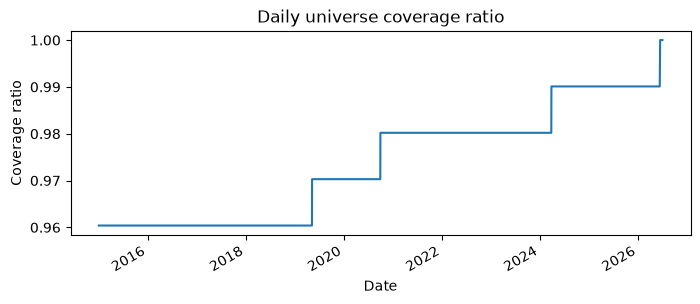

In [13]:
ax = daily_coverage.plot(
    x="date",
    y="coverage_ratio",
    figsize=(8, 3),
    title="Daily universe coverage ratio",
    legend=False,
)

ax.set_ylabel("Coverage ratio")
ax.set_xlabel("Date")
plt.show()

In [15]:
history = report["available_history_by_ticker"]
history.head(10)

,ticker,first_date,last_date,observations,missing_adj_close,missing_volume
0,HONA,2026-06-15,2026-07-02,13,0,0
1,GEV,2024-03-27,2026-07-02,568,0,0
2,PLTR,2020-09-30,2026-07-02,1445,0,0
3,UBER,2019-05-10,2026-07-02,1796,0,0
4,AAPL,2015-01-02,2026-07-02,2891,0,0
5,ABBV,2015-01-02,2026-07-02,2891,0,0
6,ABT,2015-01-02,2026-07-02,2891,0,0
7,ACN,2015-01-02,2026-07-02,2891,0,0
8,ADBE,2015-01-02,2026-07-02,2891,0,0
9,AMAT,2015-01-02,2026-07-02,2891,0,0


In [17]:
bad_prices = report["non_positive_prices"]
bad_prices.head()

,date,ticker,open,high,low,close,adj_close,volume


In [19]:
extreme_returns = report["extreme_returns"]
extreme_returns.head(20)

,date,ticker,adj_close,ret_1d,volume
89999,2016-07-05,DHR,67.727325,0.612184,1.764880e+07
17674,2016-04-22,AMD,3.990000,0.522901,1.432653e+08
256650,2020-03-19,UBER,20.490000,0.382591,8.398870e+07
211420,2025-09-10,ORCL,325.759338,0.359488,1.316181e+08
199006,2022-04-20,NFLX,22.618999,-0.351166,1.333875e+09
127773,2026-06-16,HONA,269.950012,0.349750,7.300000e+03
221139,2024-02-06,PLTR,21.870001,0.308014,4.205019e+08
206312,2016-11-11,NVDA,2.160569,0.298067,2.175344e+09
240562,2020-11-09,SPG,58.372555,0.278694,2.499620e+07
240396,2020-03-16,SPG,46.718819,-0.267127,5.743600e+06


In [20]:
gaps = report["price_gaps"]
gaps.head(20)

,date,ticker,open,prev_close,open_to_prev_close,volume
127773,2026-06-16,HONA,297.500000,200.000000,0.487500,7.300000e+03
20051,2025-10-06,AMD,226.449997,164.669998,0.375175,2.488596e+08
211420,2025-09-10,ORCL,319.190002,241.509995,0.321643,1.316181e+08
199006,2022-04-20,NFLX,24.520000,34.861000,-0.296635,1.333875e+09
133369,2025-09-18,INTC,31.780001,24.900000,0.276305,5.239080e+08
207955,2023-05-25,NVDA,38.522999,30.538000,0.261477,1.543911e+09
70687,2020-03-09,COP,33.950001,45.330002,-0.251048,2.982860e+07
176010,2022-10-27,META,97.980003,129.820007,-0.245263,2.323166e+08
133087,2024-08-02,INTC,21.940001,29.049999,-0.244750,3.008959e+08
175826,2022-02-03,META,244.649994,323.000000,-0.242570,1.881199e+08


In [21]:
sector_coverage = report["sector_coverage"]
sector_coverage

,sector,universe_tickers,available_tickers,missing_tickers,coverage_ratio
0,Communication Services,9,9,0,1.0
1,Consumer Discretionary,9,9,0,1.0
2,Consumer Staples,9,9,0,1.0
3,Energy,3,3,0,1.0
4,Financials,15,15,0,1.0
5,Health Care,15,15,0,1.0
6,Industrials,15,15,0,1.0
7,Information Technology,20,20,0,1.0
8,Materials,1,1,0,1.0
9,Real Estate,2,2,0,1.0


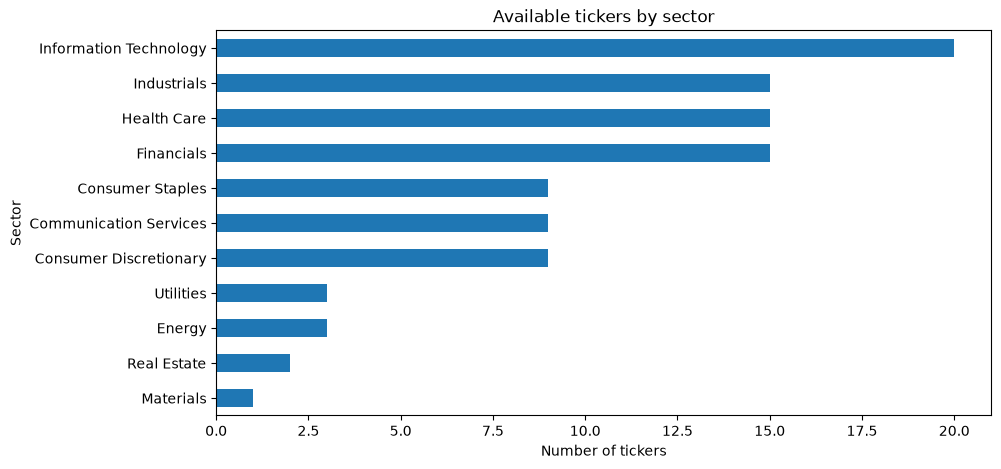

In [22]:
ax = sector_coverage.sort_values("available_tickers").plot(
    x="sector",
    y="available_tickers",
    kind="barh",
    figsize=(10, 5),
    title="Available tickers by sector",
    legend=False,
)

ax.set_xlabel("Number of tickers")
ax.set_ylabel("Sector")
plt.show()

### Cell 3 — Prepare adjusted return panel preview

In [23]:
clean_prices = prepare_ohlcv(prices)

returns = clean_prices[["date", "ticker", "ret_1d"]].copy()
returns.head()

,date,ticker,ret_1d
0,2015-01-02,AAPL,NaN
1,2015-01-05,AAPL,-0.028172
2,2015-01-06,AAPL,0.000094
3,2015-01-07,AAPL,0.014022
4,2015-01-08,AAPL,0.038422


In [24]:
returns["ret_1d"].describe(percentiles=[0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999])

count    284148.000000
mean          0.000729
std           0.019580
min          -0.351166
0.1%         -0.111360
1%           -0.053618
5%           -0.027628
50%           0.000723
95%           0.028277
99%           0.056172
99.9%         0.122961
max           0.612184
Name: ret_1d, dtype: float64

### Cell 4 — Save diagnostic tables

In [25]:
diagnostics_dir = PROCESSED_DATA_DIR / "diagnostics"
diagnostics_dir.mkdir(parents=True, exist_ok=True)

for name, df in report.items():
    df.to_csv(diagnostics_dir / f"{name}.csv", index=False)

print(f"Saved diagnostics to: {diagnostics_dir}")

Saved diagnostics to: D:\dev\quant_projects\alpha-research-lab\data\processed\diagnostics


## Check processed return panel

In [1]:
from alpha_research.config.paths import PROCESSED_DATA_DIR
from alpha_research.data_loader import load_parquet

panel = load_parquet(PROCESSED_DATA_DIR / "equity_panel.parquet")

panel.head()

,date,ticker,open,high,low,close,adj_close,volume,ret_1d,ret_5d,ret_21d,forward_ret_1d,forward_ret_5d,dollar_volume,log_dollar_volume,original_ticker,name,sector
0,2015-01-02,AAPL,27.847500,27.860001,26.837500,27.332500,24.192612,212818400.0,NaN,NaN,NaN,-0.028172,0.024512,5.148633e+09,22.361997,AAPL,Apple Inc.,Information Technology
1,2015-01-05,AAPL,27.072500,27.162500,26.352501,26.562500,23.511065,257142000.0,-0.028172,NaN,NaN,0.000094,0.028235,6.045682e+09,22.522610,AAPL,Apple Inc.,Information Technology
2,2015-01-06,AAPL,26.635000,26.857500,26.157499,26.565001,23.513273,263188400.0,0.000094,NaN,NaN,0.014022,0.037267,6.188421e+09,22.545946,AAPL,Apple Inc.,Information Technology
3,2015-01-07,AAPL,26.799999,27.049999,26.674999,26.937500,23.842987,160423600.0,0.014022,NaN,NaN,0.038422,0.019025,3.824978e+09,22.064819,AAPL,Apple Inc.,Information Technology
4,2015-01-08,AAPL,27.307501,28.037500,27.174999,27.972500,24.759081,237458000.0,0.038422,NaN,NaN,0.001072,-0.045313,5.879242e+09,22.494694,AAPL,Apple Inc.,Information Technology


In [2]:
panel[["ticker", "name", "sector"]].drop_duplicates().head(20)

,ticker,name,sector
0,AAPL,Apple Inc.,Information Technology
2891,ABBV,AbbVie,Health Care
5782,ABT,Abbott Laboratories,Health Care
8673,ACN,Accenture,Information Technology
11564,ADBE,Adobe Inc.,Information Technology
14455,AMAT,Applied Materials,Information Technology
17346,AMD,Advanced Micro Devices,Information Technology
20237,AMGN,Amgen,Health Care
23128,AMT,American Tower,Real Estate
26019,AMZN,Amazon,Consumer Discretionary


In [3]:
panel.loc[
    panel["sector"].isna(),
    ["ticker", "name", "sector"],
].drop_duplicates()

,ticker,name,sector


In [4]:
panel[
    ["ret_1d", "ret_5d", "ret_21d", "forward_ret_1d", "forward_ret_5d"]
].describe(
    percentiles=[0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]
)

,ret_1d,ret_5d,ret_21d,forward_ret_1d,forward_ret_5d
count,284148.000000,283744.000000,282136.000000,284148.000000,283744.000000
mean,0.000729,0.003603,0.015121,0.000729,0.003603
std,0.019580,0.042667,0.086870,0.019580,0.042667
min,-0.351166,-0.557439,-0.717468,-0.351166,-0.557439
0.1%,-0.111360,-0.206657,-0.376435,-0.111360,-0.206657
1%,-0.053618,-0.113546,-0.198235,-0.053618,-0.113546
5%,-0.027628,-0.061104,-0.111990,-0.027628,-0.061104
50%,0.000723,0.003676,0.013364,0.000723,0.003676
95%,0.028277,0.066759,0.147578,0.028277,0.066759
99%,0.056172,0.124350,0.265366,0.056172,0.124350


## Check extended factor columns

In [5]:
from alpha_research.config.paths import PROCESSED_DATA_DIR
from alpha_research.data_loader import load_parquet
from alpha_research.factors import add_raw_factors

panel = load_parquet(PROCESSED_DATA_DIR / "equity_panel.parquet")

factor_preview = add_raw_factors(panel)

factor_preview[
    [
        "date",
        "ticker",
        "adj_close",
        "mom_12_1m_raw",
        "mom_3m_raw",
        "reversal_1m_raw",
        "realised_vol_63_raw",
    ]
].tail()

,date,ticker,adj_close,mom_12_1m_raw,mom_3m_raw,reversal_1m_raw,realised_vol_63_raw
284244,2026-06-26,XOM,136.539993,0.408272,-0.169034,0.076809,0.313147
284245,2026-06-29,XOM,136.059998,0.378712,-0.198880,0.074170,0.304309
284246,2026-06-30,XOM,136.720001,0.370363,-0.197247,0.058791,0.304504
284247,2026-07-01,XOM,136.279999,0.429886,-0.191294,0.087696,0.304146
284248,2026-07-02,XOM,136.679993,0.412737,-0.144124,0.086119,0.287468


In [6]:
factor_columns = [
    "mom_12_1m_raw",
    "mom_3m_raw",
    "reversal_1m_raw",
    "realised_vol_63_raw",
]

factor_preview[factor_columns].notna().mean()

mom_12_1m_raw          0.911300
mom_3m_raw             0.977791
reversal_1m_raw        0.992566
realised_vol_63_raw    0.977791
dtype: float64

In [10]:
factor_coverage = (
    factor_preview.groupby("date")[factor_columns]
    .count()
    .reset_index()
)

factor_coverage.tail()

,date,mom_12_1m_raw,mom_3m_raw,reversal_1m_raw,realised_vol_63_raw
2886,2026-06-26,100,100,100,100
2887,2026-06-29,100,100,100,100
2888,2026-06-30,100,100,100,100
2889,2026-07-01,100,100,100,100
2890,2026-07-02,100,100,100,100


In [15]:
ticker = "AAPL"
sample_date = factor_preview["date"].max()

stock = (
    factor_preview.query("ticker == @ticker")
    .sort_values("date")
    .reset_index(drop=True)
)

row = stock.loc[stock["date"] == sample_date].iloc[0]
position = stock.index[stock["date"] == sample_date][0]

manual_mom_3m = (
    stock["adj_close"].iloc[position]
    / stock["adj_close"].iloc[position - 63]
    - 1.0
)

row["mom_3m_raw"], manual_mom_3m, row["mom_3m_raw"] - manual_mom_3m

(np.float64(0.2040969922295066),
 np.float64(0.2040969922295066),
 np.float64(0.0))

## Factor panel sanity check

In [17]:
from alpha_research.config.paths import PROCESSED_DATA_DIR
from alpha_research.data_loader import load_parquet

factor_panel = load_parquet(
    PROCESSED_DATA_DIR / "factor_panel.parquet"
)

factor_panel.tail()

,date,ticker,open,high,low,close,adj_close,volume,ret_1d,ret_5d,...,mom_12_1m_rank,mom_3m_winsorised,mom_3m_z,mom_3m_rank,reversal_1m_winsorised,reversal_1m_z,reversal_1m_rank,realised_vol_63_winsorised,realised_vol_63_z,realised_vol_63_rank
284244,2026-06-26,XOM,136.970001,137.580002,135.919998,136.539993,136.539993,22684200.0,-0.007343,-0.009216,...,0.77,-0.169034,-0.834713,0.11,0.076809,0.826331,0.77,0.313147,-0.284306,0.53
284245,2026-06-29,XOM,136.580002,137.389999,135.389999,136.059998,136.059998,11972700.0,-0.003515,-0.017405,...,0.75,-0.198880,-0.920037,0.06,0.074170,0.732941,0.73,0.304309,-0.330315,0.52
284246,2026-06-30,XOM,136.479996,137.300003,135.330002,136.720001,136.720001,28784000.0,0.004851,-0.021542,...,0.76,-0.197247,-0.810175,0.08,0.058791,0.479319,0.72,0.304504,-0.333698,0.50
284247,2026-07-01,XOM,136.529999,137.490005,135.630005,136.279999,136.279999,12418600.0,-0.003218,-0.004529,...,0.78,-0.191294,-0.884366,0.07,0.087696,0.798831,0.82,0.304146,-0.330729,0.49
284248,2026-07-02,XOM,137.149994,139.119995,136.330002,136.679993,136.679993,8180166.0,0.002935,-0.006325,...,0.77,-0.144124,-0.911657,0.07,0.086119,0.914223,0.81,0.287468,-0.438983,0.41


In [18]:
latest_date = factor_panel["date"].max()

latest = factor_panel.loc[
    factor_panel["date"] == latest_date
]

latest[
    [
        "ticker",
        "mom_12_1m_raw",
        "mom_12_1m_z",
        "mom_12_1m_rank",
    ]
].sort_values("mom_12_1m_rank", ascending=False).head(10)

,ticker,mom_12_1m_raw,mom_12_1m_z,mom_12_1m_rank
194277,MU,7.823286,4.913699,1.00
133566,INTC,3.723414,4.855851,0.99
20236,AMD,2.831754,3.597757,0.98
162476,LRCX,2.470965,3.088699,0.97
17345,AMAT,1.686357,1.981650,0.96
60710,CAT,1.352544,1.510655,0.95
121989,GOOGL,1.062475,1.101380,0.94
119098,GOOG,1.030395,1.056116,0.93
110425,GEV,0.920550,0.901130,0.92
80947,CSCO,0.895025,0.865115,0.91


In [19]:
latest["mom_12_1m_z"].mean(), latest["mom_12_1m_z"].std(ddof=0)

(np.float64(-2.4147350785597155e-17), np.float64(1.0))

In [20]:
factor_columns = [
    "mom_12_1m_raw",
    "mom_3m_raw",
    "reversal_1m_raw",
    "realised_vol_63_raw",
]

coverage = (
    factor_panel.groupby("date")[factor_columns]
    .count()
    .reset_index()
)

coverage.tail()

,date,mom_12_1m_raw,mom_3m_raw,reversal_1m_raw,realised_vol_63_raw
2886,2026-06-26,100,100,100,100
2887,2026-06-29,100,100,100,100
2888,2026-06-30,100,100,100,100
2889,2026-07-01,100,100,100,100
2890,2026-07-02,100,100,100,100
